In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed

torch.manual_seed(0)
np.random.seed(0)

# 1. Same stock as Day 1
feed = DataFeed.from_dir('data/egx', symbols=['ABUK'])
returns = feed.returns[:, 0]
print(f"{len(returns)} days of data for {feed.symbols[0]}")

2857 days of data for ABUK


In [2]:
LOOKBACK = 10  # same window size as Day 1, for a fair comparison

X, y = [], []
for t in range(LOOKBACK, len(returns) - 1):
    X.append(returns[t - LOOKBACK:t])
    y.append(returns[t + 1])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32).reshape(-1, 1)

# reshape for LSTM: (samples, sequence_length, features=1)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Same chronological split as Day 1 — train on the past, test on the future
split = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(f"train: {len(X_train)} days | test: {len(X_test)} days")

train: 1992 days | test: 854 days


In [3]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_hidden = out[:, -1, :]   # only the final timestep's output — the "memory" after seeing the whole window
        return self.fc(last_hidden)

model = LSTMPredictor()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [4]:
EPOCHS = 200
train_losses, test_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()
    pred_train = model(X_train_t)
    loss_train = loss_fn(pred_train, y_train_t)
    loss_train.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_t)
        loss_test = loss_fn(pred_test, y_test_t)

    train_losses.append(loss_train.item())
    test_losses.append(loss_test.item())

    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  train_loss={loss_train.item():.6f}  test_loss={loss_test.item():.6f}")

print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final test loss:  {test_losses[-1]:.6f}")


epoch   0  train_loss=0.014710  test_loss=0.013628
epoch  20  train_loss=0.000881  test_loss=0.000934
epoch  40  train_loss=0.000666  test_loss=0.000845
epoch  60  train_loss=0.000494  test_loss=0.000692
epoch  80  train_loss=0.000485  test_loss=0.000682
epoch 100  train_loss=0.000485  test_loss=0.000682
epoch 120  train_loss=0.000485  test_loss=0.000681
epoch 140  train_loss=0.000485  test_loss=0.000681
epoch 160  train_loss=0.000485  test_loss=0.000681
epoch 180  train_loss=0.000485  test_loss=0.000681
Final train loss: 0.000485
Final test loss:  0.000681


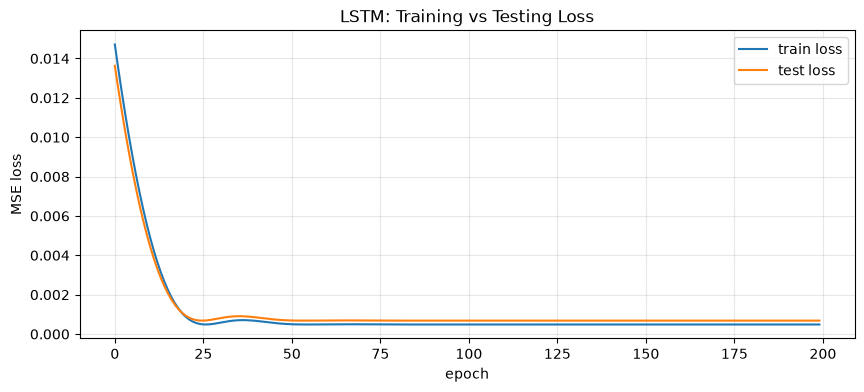

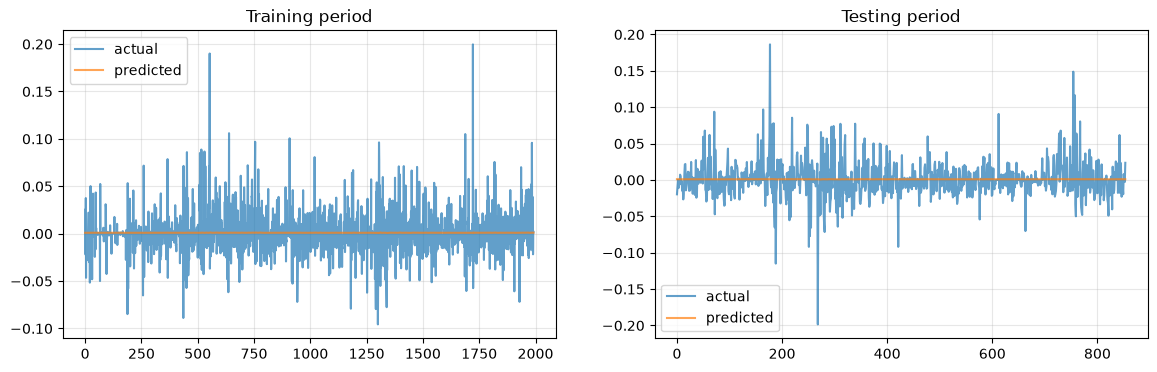

In [5]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.xlabel('epoch'); plt.ylabel('MSE loss')
plt.legend(); plt.grid(alpha=0.3); plt.title('LSTM: Training vs Testing Loss')
plt.show()

model.eval()
with torch.no_grad():
    pred_train_final = model(X_train_t).squeeze().numpy()
    pred_test_final = model(X_test_t).squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_train.flatten(), label='actual', alpha=0.7)
axes[0].plot(pred_train_final, label='predicted', alpha=0.7)
axes[0].set_title('Training period'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(y_test.flatten(), label='actual', alpha=0.7)
axes[1].plot(pred_test_final, label='predicted', alpha=0.7)
axes[1].set_title('Testing period'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.show()

In [7]:
DAY1_MLP_FINAL_TEST_LOSS = 0.000679  # <-- paste your actual Day 1 MLP final test loss here

lstm_final_test_loss = test_losses[-1]

print(f"Day 1 MLP  final test loss: {DAY1_MLP_FINAL_TEST_LOSS:.6f}")
print(f"Day 2 LSTM final test loss: {lstm_final_test_loss:.6f}")

if lstm_final_test_loss < DAY1_MLP_FINAL_TEST_LOSS:
    print(f"\nLSTM beat the MLP by {DAY1_MLP_FINAL_TEST_LOSS - lstm_final_test_loss:.6f} — memory helped here.")
else:
    print(f"\nLSTM did NOT beat the MLP (worse by {lstm_final_test_loss - DAY1_MLP_FINAL_TEST_LOSS:.6f}) — yesterday's win may not carry over.")

Day 1 MLP  final test loss: 0.000679
Day 2 LSTM final test loss: 0.000681

LSTM did NOT beat the MLP (worse by 0.000002) — yesterday's win may not carry over.


In [8]:
# MLP from Day 1 or LSTM from Day 2
LOOKBACK = 10

def predict_next_return(model, recent_returns, is_lstm=False):
    """Feed the model the last LOOKBACK days and get back its predicted next-day return."""
    x = np.array(recent_returns[-LOOKBACK:], dtype=np.float32)
    if is_lstm:
        x_t = torch.tensor(x).reshape(1, LOOKBACK, 1)  # (batch, seq_len, features)
    else:
        x_t = torch.tensor(x).reshape(1, LOOKBACK)      # (batch, flat features)

    model.eval()
    with torch.no_grad():
        pred = model(x_t).item()
    return pred

# check on the single stock you already loaded
recent = returns[-(LOOKBACK + 1):-1]   # last 10 days, not including "today"
predicted_return = predict_next_return(model, recent, is_lstm=True)  # set is_lstm=False for the MLP

print(f"Predicted next-day return: {predicted_return:+.5f}")
print("Signal:", "ENTRY (go long)" if predicted_return > 0 else "EXIT (go flat)")

Predicted next-day return: +0.00094
Signal: ENTRY (go long)


In [9]:
def neural_predictor_weights(observation, model, lookback=LOOKBACK, is_lstm=False):
    """
    Same shape and contract as sma_crossover_weights from Notebook 3:
    takes an observation (n_assets, window, features), returns a weights
    array that sums to 1 (or all zeros if nothing signals a buy).
    """
    n_assets = observation.shape[0]
    hold = np.zeros(n_assets)

    for asset in range(n_assets):
        daily_returns = observation[asset, :, 0]

        if len(daily_returns) < lookback:
            continue  # not enough history yet

        recent = daily_returns[-lookback:]
        pred = predict_next_return(model, recent, is_lstm=is_lstm)

        if pred > 0:
            hold[asset] = 1.0

    if hold.sum() == 0:
        return np.zeros(n_assets)  # no positive signals anywhere -> hold cash

    weights = hold / hold.sum()  # equal-weight split across everything with a positive signal
    return weights

In [10]:
from tradinglab.observation import build_observation

# load the FULL universe this time, not just one stock
feed_full = DataFeed.from_dir('data/egx')  # all symbols

t = 500  # pick a day with enough history
obs_full = build_observation(feed_full, t, lookback=LOOKBACK)

weights_today = neural_predictor_weights(obs_full, model, lookback=LOOKBACK, is_lstm=True)

print("Portfolio weights for today, across the full universe:\n")
for sym, w in zip(feed_full.symbols, weights_today):
    print(f"  {sym:6s}  {'HOLD' if w > 0 else 'cash':5s}  weight={w:.3f}")

assert abs(weights_today.sum() - 1) < 1e-9 or weights_today.sum() == 0, "weights should sum to 1 or be all zero"
print("\nWeights are valid ✓")

Portfolio weights for today, across the full universe:

  ABUK    HOLD   weight=0.029
  ADIB_   HOLD   weight=0.029
  ALCN    HOLD   weight=0.029
  AMOC    HOLD   weight=0.029
  ARCC    HOLD   weight=0.029
  BTFH    HOLD   weight=0.029
  CCAP    HOLD   weight=0.029
  CIEB    HOLD   weight=0.029
  COMI    HOLD   weight=0.029
  DOMTY   HOLD   weight=0.029
  EAST    HOLD   weight=0.029
  EFID    HOLD   weight=0.029
  EFIH    HOLD   weight=0.029
  EGAL    HOLD   weight=0.029
  EMFD    HOLD   weight=0.029
  ETEL    HOLD   weight=0.029
  FWRY    HOLD   weight=0.029
  GBCO    HOLD   weight=0.029
  HELI    HOLD   weight=0.029
  HRHO    HOLD   weight=0.029
  ISPH    HOLD   weight=0.029
  JUFO    HOLD   weight=0.029
  MCQE    HOLD   weight=0.029
  MFPC    HOLD   weight=0.029
  ORAS    HOLD   weight=0.029
  ORWE    HOLD   weight=0.029
  PHDC    HOLD   weight=0.029
  RAYA    HOLD   weight=0.029
  RMDA    HOLD   weight=0.029
  SAUD    HOLD   weight=0.029
  SKPC    HOLD   weight=0.029
  SUGR    HOLD

In [ ]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["MLP (Day 1)", "LSTM (Day 2)"],
    "Lookback (days)": [1, LOOKBACK],  # MLP used only the previous day's return as its feature, not a 10-day window
    "Final Test Loss": [DAY1_MLP_FINAL_TEST_LOSS, lstm_final_test_loss],
})
model_comparison["Winner"] = model_comparison["Final Test Loss"] == model_comparison["Final Test Loss"].min()
model_comparison["Winner"] = model_comparison["Winner"].map({True: "✓ Lower test loss", False: ""})

print("=== Model Comparison: MLP vs LSTM ===")
display(model_comparison.style.hide(axis="index"))


# === Table 2: Portfolio Composition — using weights_today and feed_full from the cell above ===
n_total = len(feed_full.symbols)
n_holding = int((weights_today > 0).sum())
n_cash = n_total - n_holding
weight_per_stock = 1 / n_holding if n_holding > 0 else 0

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Total universe size",
        "Stocks held (positive signal)",
        "Stocks in cash (no signal)",
        "Equal weight per held stock",
        "Model used for signals",
    ],
    "Value": [n_total, n_holding, n_cash, f"{weight_per_stock:.3f}", "LSTM"],
})

print("\n=== Portfolio Composition (Full Universe, Day t={}) ===".format(t))
display(portfolio_summary.style.hide(axis="index"))

In [ ]:
mlp_train_losses = [
    0.00085475790547207, 0.0006214064196683466, 0.0005066331359557807, 0.000494354753755033, 0.0005398207576945424, 0.0005843339022248983,
    0.0005957864923402667, 0.0005761877400800586, 0.0005420365487225354, 0.0005100909620523453, 0.000491483835503459, 0.0004896425525657833,
    0.0005005226703360677, 0.0005154412356205285, 0.0005257839220575988, 0.0005269575631245971, 0.0005194550612941384, 0.0005073518259450793,
    0.0004958278150297701, 0.0004889335250481963, 0.00048819207586348057, 0.0004923312808386981, 0.0004981959355063736, 0.0005024170386604965,
    0.0005029746680520475, 0.0004998802323825657, 0.000494806154165417, 0.0004900505882687867, 0.00048741637147031724, 0.0004874796140938997,
    0.0004895016900263727, 0.0004919597995467484, 0.0004933863529004157, 0.0004930661525577307, 0.000491261831484735, 0.0004889294505119324,
    0.0004871428245678544, 0.0004865479131694883, 0.00048710222472436726, 0.00048819530638866127, 0.0004890451091341674, 0.000489130849018693,
    0.0004884263616986573, 0.0004873361613135785, 0.000486411910969764, 0.00048603254253976047, 0.00048622494796290994, 0.0004867021052632481,
    0.0004870707052759826, 0.0004870671546086669, 0.0004866858944296837, 0.0004861416819039732, 0.00048571114894002676, 0.00048556295223534107,
    0.0004856758168898523, 0.0004858802421949804, 0.0004859826003666967, 0.00048588530626147985, 0.0004856303858105093, 0.0004853510472457856,
    0.0004851754929404706, 0.00048514752415940166, 0.0004852130950894207, 0.000485269702039659, 0.00048523920122534037, 0.0004851137928199023,
    0.00048494929797016084, 0.0004848186217714101, 0.0004847614327445626, 0.00048476317897439003, 0.0004847737436648458, 0.00048474635696038604,
    0.0004846688243560493, 0.00048456553486175835, 0.0004844753129873425, 0.0004844218783546239, 0.0004844003124162555, 0.0004843849455937743,
    0.0004843508650083095, 0.00048429123125970364, 0.0004842189373448491, 0.00048415447236038744, 0.0004841093614231795, 0.00048407999565824866,
    0.0004840523179154843, 0.0004840140463784337, 0.0004839632019866258, 0.00048390787560492754, 0.0004838586028199643, 0.0004838199820369482,
    0.00048378814244642854, 0.0004837552842218429, 0.00048371616867370903, 0.0004836715233977884, 0.0004836267326027155, 0.00048358659842051566,
    0.0004835519357584417, 0.0004835195140913129, 0.00048348522977903485, 0.00048344762763008475, 0.00048340842477045953, 0.0004833706479985267,
    0.000483336130855605, 0.0004833039129152894, 0.00048327192780561745, 0.0004832384001929313, 0.0004832036793231964, 0.00048316913307644427,
    0.0004831362748518586, 0.0004831051919609308, 0.0004830748657695949, 0.0004830440448131412, 0.00048301261267624795, 0.0004829811805393547,
    0.0004829506215173751, 0.00048292119754478335, 0.000482892501167953, 0.00048286395031027496, 0.0004828350793104619, 0.00048280629562214017,
    0.0004827780358027667, 0.00048275053268298507, 0.0004827236698474735, 0.0004826970398426056, 0.0004826704680453986, 0.00048264398355968297,
    0.00048261790652759373, 0.0004825923824682832, 0.00048256738227792084, 0.0004825426731258631, 0.00048251808038912714, 0.00048249372048303485,
    0.00048246965161524713, 0.0004824460775125772, 0.00048242282355204225, 0.00048239994794130325, 0.00048237727605737746, 0.00048235480790026486,
    0.0004823326598852873, 0.00048231089022010565, 0.0004822894115932286, 0.000482268282212317, 0.00048224732745438814, 0.0004822266928385943,
    0.0004822062619496137, 0.00048218623851425946, 0.0004821664479095489, 0.00048214694834314287, 0.00048212771071121097, 0.0004821087059099227,
    0.00048208999214693904, 0.000482071511214599, 0.000482053350424394, 0.00048203542246483266, 0.00048201772733591497, 0.0004820003523491323,
    0.00048198315198533237, 0.00048196621355600655, 0.00048194953706115484, 0.0004819330933969468, 0.0004819168825633824, 0.00048190090456046164,
    0.000481885188492015, 0.00048186967615038157, 0.00048185442574322224, 0.00048183934995904565, 0.00048182453610934317, 0.00048180995509028435,
    0.0004817955777980387, 0.0004817814042326063, 0.00048176743439398706, 0.0004817537555936724, 0.00048174022231251, 0.00048172689275816083,
    0.00048171376693062484, 0.0004817008739337325, 0.0004816881555598229, 0.000481675670016557, 0.0004816633590962738, 0.0004816512227989733,
    0.00048163929022848606, 0.0004816275031771511, 0.0004816159780602902, 0.00048160459846258163, 0.00048159342259168625, 0.00048158239223994315,
    0.0004815715365111828, 0.00048156085540540516, 0.00048155037802644074, 0.00048154007527045906, 0.00048152991803362966, 0.00048151996452361345,
    0.0004815101274289191, 0.00048150046495720744, 0.0004814909480046481, 0.0004814816056750715, 0.00048147246707230806, 0.0004814634448848665,
    0.0004814544809050858, 0.00048144583706744015,
]

mlp_test_losses = [
    0.0008155051036737859, 0.0007021133787930012, 0.0006910552619956434, 0.0007374298293143511, 0.0007824358181096613, 0.0007939909119158983,
    0.0007741987938061357, 0.0007396551081910729, 0.00070719956420362, 0.0006880360306240618, 0.0006856578402221203, 0.0006960806786082685,
    0.0007106686825864017, 0.0007208332535810769, 0.0007219835533760488, 0.0007145957206375897, 0.0007027159444987774, 0.0006914879777468741,
    0.0006849227356724441, 0.0006845035240985453, 0.0006889206124469638, 0.0006949891685508192, 0.0006993212155066431, 0.0006998912431299686,
    0.00069671799428761, 0.0006914913537912071, 0.0006865337491035461, 0.0006836763932369649, 0.0006835245876573026, 0.0006853657541796565,
    0.0006876976112835109, 0.0006890640943311155, 0.000688752334099263, 0.0006870177458040416, 0.0006848023622296751, 0.0006831603241153061,
    0.00068271579220891, 0.0006834053201600909, 0.0006846007308922708, 0.0006855083629488945, 0.0006856026593595743, 0.0006848605698905885,
    0.0006836956599727273, 0.0006826737662777305, 0.0006821902352385223, 0.0006822879076935351, 0.0006826936732977629, 0.0006830230704508722,
    0.0006830161437392235, 0.000682665326166898, 0.0006821777205914259, 0.0006818193360231817, 0.0006817464018240571, 0.0006819254485890269,
    0.0006821774295531213, 0.0006823030416853726, 0.0006822030991315842, 0.0006819227710366249, 0.0006816020468249917, 0.0006813777727074921,
    0.0006813033251091838, 0.0006813331274315715, 0.0006813703803345561, 0.000681339530274272, 0.0006812317878939211, 0.0006810990162193775,
    0.0006810079794377089, 0.000680991041008383, 0.0006810272461734712, 0.0006810611230321229, 0.0006810436607338488, 0.0006809626356698573,
    0.0006808452308177948, 0.0006807345780543983, 0.0006806598394177854, 0.0006806211895309389, 0.0006805967423133552, 0.0006805636221542954,
    0.0006805150187574327, 0.0006804617587476969, 0.0006804208969697356, 0.0006804000004194677, 0.0006803917931392789, 0.0006803791620768607,
    0.0006803486030548811, 0.0006802984862588346, 0.0006802385323680937, 0.0006801818963140249, 0.0006801364361308515, 0.0006801008130423725,
    0.0006800691480748355, 0.0006800368428230286, 0.0006800040719099343, 0.0006799745606258512, 0.0006799512775614858, 0.000679932301864028,
    0.0006799129187129438, 0.0006798878312110901, 0.0006798554677516222, 0.0006798182148486376, 0.0006797808455303311, 0.0006797465030103922,
    0.0006797162350267172, 0.0006796888192184269, 0.0006796628586016595, 0.0006796385277993977, 0.0006796164670959115, 0.0006795965600758791,
    0.0006795779336243868, 0.0006795584922656417, 0.0006795363733544946, 0.0006795114604756236, 0.0006794850341975689, 0.000679458724334836,
    0.0006794339278712869, 0.0006794108776375651, 0.0006793895736336708, 0.0006793698412366211, 0.0006793515640310943, 0.0006793345091864467,
    0.0006793182110413909, 0.000679302029311657, 0.0006792849744670093, 0.0006792667554691434, 0.000679247488733381, 0.0006792282219976187,
    0.0006792094209231436, 0.000679191667586565, 0.0006791749619878829, 0.0006791595369577408, 0.0006791450432501733, 0.0006791314808651805,
    0.000679118325933814, 0.0006791054038330913, 0.000679092132486403, 0.0006790784536860883, 0.0006790643674321473, 0.0006790502811782062,
    0.0006790365441702306, 0.000679023505654186, 0.0006790111656300724, 0.0006789996405132115, 0.0006789888720959425, 0.0006789785693399608,
    0.0006789686740376055, 0.0006789588951505721, 0.0006789490580558777, 0.0006789389299228787, 0.0006789289182052016, 0.0006789189646951854,
    0.0006789093022234738, 0.0006789001054130495, 0.0006788916070945561, 0.00067888357443735, 0.0006788760656490922, 0.0006788687314838171,
    0.0006788616883568466, 0.0006788548198528588, 0.0006788478931412101, 0.0006788409664295614, 0.0006788341561332345, 0.0006788276368752122,
    0.0006788213504478335, 0.0006788154132664204, 0.0006788099417462945, 0.0006788048194721341, 0.0006787999300286174, 0.0006787953316234052,
    0.0006787909078411758, 0.0006787865422666073, 0.0006787821184843779, 0.000678777985740453, 0.0006787737947888672, 0.0006787700694985688,
    0.0006787664024159312, 0.000678763200994581, 0.0006787601741962135, 0.0006787573802284896, 0.0006787548772990704, 0.0006787524907849729,
    0.0006787501042708755, 0.0006787479505874217, 0.000678745680488646, 0.0006787437596358359, 0.0006787419551983476, 0.000678740325383842,
    0.0006787389283999801, 0.0006787377642467618, 0.0006787367747165263, 0.0006787358433939517, 0.0006787352031096816, 0.0006787345628254116,
    0.0006787339225411415, 0.0006787335150875151, 0.0006787331658415496, 0.0006787329912185669, 0.0006787330494262278, 0.0006787331076338887,
    0.0006787334568798542, 0.0006787338061258197,
]

plt.figure(figsize=(10, 4))
plt.plot(mlp_train_losses, label='MLP train loss')
plt.plot(mlp_test_losses, label='MLP test loss')
plt.plot(train_losses, label='LSTM train loss')
plt.plot(test_losses, label='LSTM test loss')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.legend()
plt.grid(alpha=0.3)
plt.title('MLP vs LSTM: Training and Testing Loss')
plt.show()
